## CUSTOMER CHURN PROJECT
### DEKU ROBERT MARSH

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## CREATING A SAMPLE DATASET

In [9]:
n_samples = 1000

data = {
    'customer_id': range(1, n_samples + 1),
    'age': np.random.randint(18, 80, n_samples),
    'tenure_months': np.random.randint(1, 72, n_samples),
    'monthly_charges': np.random.uniform(20, 150, n_samples),
    'total_charges': np.random.uniform(100, 8000, n_samples),
    'contract_length': np.random.choice(['Month-to-month', '1 year', '2 year'], n_samples),
    'internet_service': np.random.choice(['DSL', 'Fiber optic', 'No'], n_samples),
    'churn': np.random.choice([0, 1], n_samples, p=[0.73, 0.27])
}

df = pd.DataFrame(data)

## DATA EXPLORATION & CLEANING
UNDERSTANDING YOUR DATA

WHAT WE'RE DOING:

Think of this like getting to know your dataset before diving deeper. We're checking:
- How many customers do we have?
- What information do we know about each customer?
- Are there any missing or broken data points?

In [58]:
print(f"Dataset shape: {df.shape}")
print(f"  We have {df.shape[0]} customers and {df.shape[1]} pieces of information per customer")

print(f"\nFirst few rows:\n{df.head()}")

print(f"\nData types:\n{df.dtypes}")

print(f"\nMissing values:\n{df.isnull().sum()}")
print("Great! No missing data. Real-world data often has holes we need to patch.")

print(f"\nBasic statistics:\n{df.describe()}")

print(f"\nDuplicate rows: {df.duplicated().sum()}")

churn_rate = df['churn'].mean()
print(f"\nChurn distribution:\n{df['churn'].value_counts()}")
print(f"\n🎯 INSIGHT: {churn_rate:.1%} of customers left us. {(1-churn_rate):.1%} stayed.")
print("This tells us the problem: we lose about 1 in 4 customers.")

Dataset shape: (1000, 8)
  We have 1000 customers and 8 pieces of information per customer

First few rows:
   customer_id  age  tenure_months  monthly_charges  total_charges  \
0            1   57             39        99.721357    3384.783971   
1            2   60             43        72.051201    7721.545009   
2            3   73             43        21.541188    5906.471863   
3            4   73              3        36.289117     588.705253   
4            5   32             46        62.248946    5982.588406   

  contract_length internet_service  churn  
0  Month-to-month      Fiber optic      0  
1  Month-to-month              DSL      0  
2          1 year              DSL      0  
3          1 year      Fiber optic      1  
4          1 year               No      0  

Data types:
customer_id           int64
age                   int32
tenure_months         int32
monthly_charges     float64
total_charges       float64
contract_length      object
internet_service     objec

## EXPLORATORY DATA ANALYSIS (EDA)

EXPLORING PATTERNS (What makes customers leave?)

WHAT WE'RE DOING:

We're looking for clues about which customers are likely to churn. Think of it like
being a detective - we want to spot the warning signs.

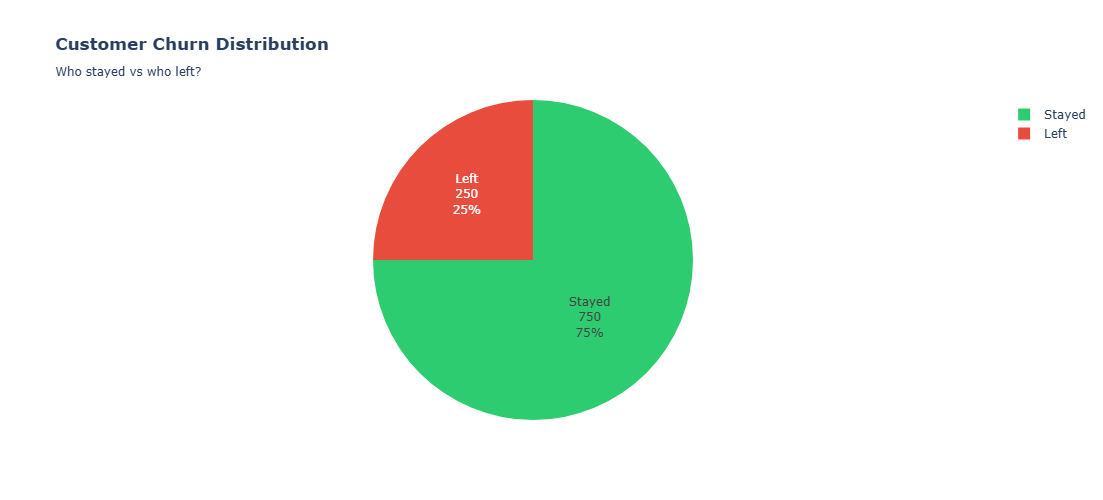

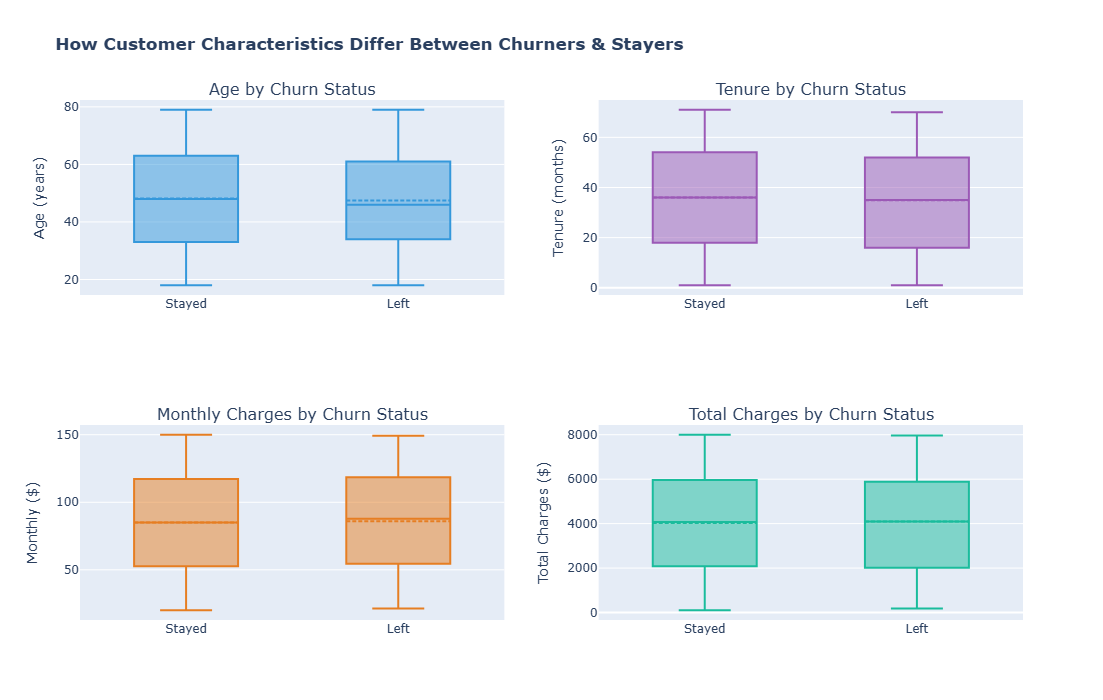

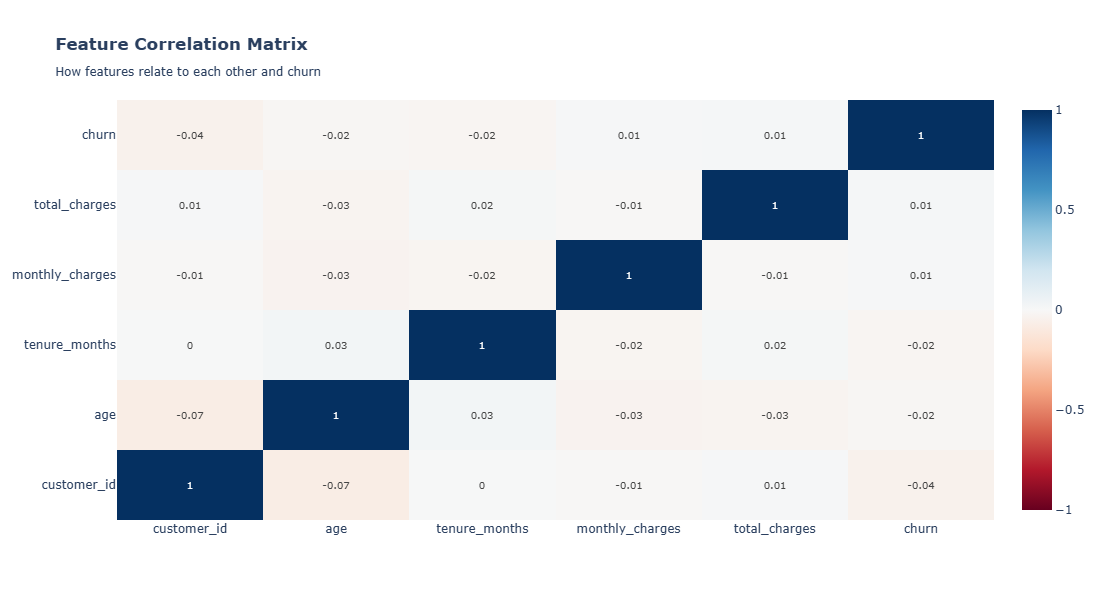

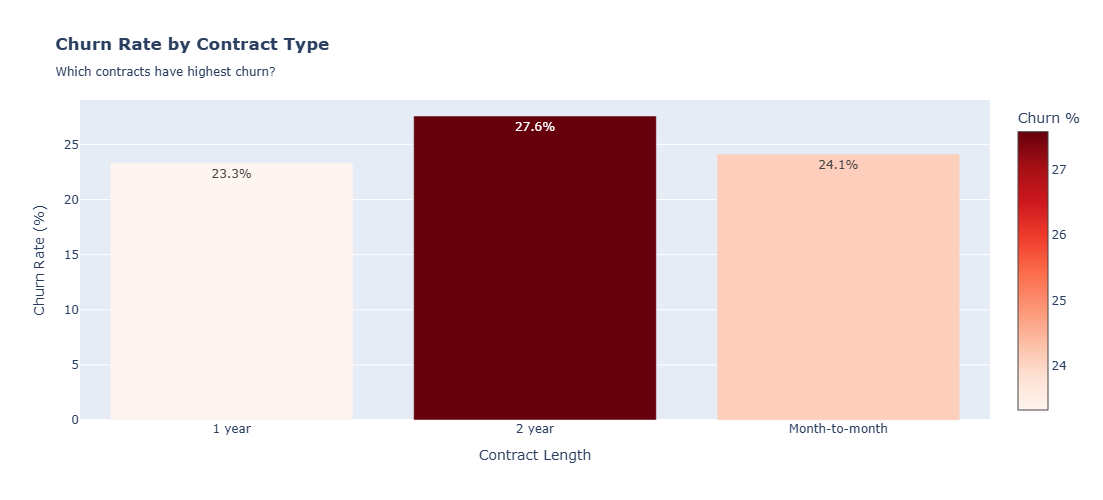

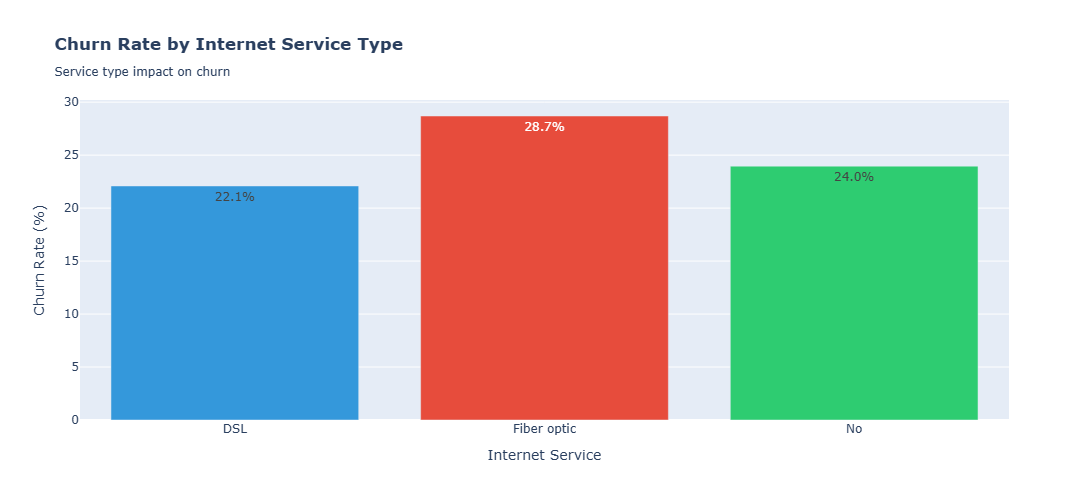


Correlation with churn:
churn              1.000000
total_charges      0.013297
monthly_charges    0.010628
age               -0.016144
tenure_months     -0.021715
customer_id       -0.044288
Name: churn, dtype: float64


In [61]:
# Visualization 1: Churn Distribution - Pie Chart
churn_counts = df['churn'].value_counts()
fig1 = go.Figure(data=[go.Pie(
    labels=['Stayed', 'Left'],
    values=[churn_counts[0], churn_counts[1]],
    marker=dict(colors=['#2ecc71', '#e74c3c']),
    textposition='inside',
    textinfo='label+percent+value',
    hovertemplate='<b>%{label}</b><br>Count: %{value}<br>Percentage: %{percent}<extra></extra>'
)])
fig1.update_layout(
    title='<b>Customer Churn Distribution</b><br><sub>Who stayed vs who left?</sub>',
    font=dict(size=12),
    height=500,
    showlegend=True
)
fig1.show()

# Visualization 2: Multi-variable distribution
fig2 = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Age by Churn Status', 'Tenure by Churn Status',
                    'Monthly Charges by Churn Status', 'Total Charges by Churn Status'),
    specs=[[{'type': 'box'}, {'type': 'box'}],
           [{'type': 'box'}, {'type': 'box'}]]
)

churn_labels = {0: 'Stayed', 1: 'Left'}

fig2.add_trace(
    go.Box(x=df['churn'].map(churn_labels), y=df['age'], name='Age', 
           marker_color='#3498db', boxmean=True),
    row=1, col=1
)
fig2.add_trace(
    go.Box(x=df['churn'].map(churn_labels), y=df['tenure_months'], name='Tenure',
           marker_color='#9b59b6', boxmean=True),
    row=1, col=2
)
fig2.add_trace(
    go.Box(x=df['churn'].map(churn_labels), y=df['monthly_charges'], name='Monthly Charges',
           marker_color='#e67e22', boxmean=True),
    row=2, col=1
)
fig2.add_trace(
    go.Box(x=df['churn'].map(churn_labels), y=df['total_charges'], name='Total Charges',
           marker_color='#1abc9c', boxmean=True),
    row=2, col=2
)

fig2.update_yaxes(title_text="Age (years)", row=1, col=1)
fig2.update_yaxes(title_text="Tenure (months)", row=1, col=2)
fig2.update_yaxes(title_text="Monthly ($)", row=2, col=1)
fig2.update_yaxes(title_text="Total Charges ($)", row=2, col=2)

fig2.update_layout(
    title_text="<b>How Customer Characteristics Differ Between Churners & Stayers</b>",
    height=700,
    showlegend=False,
    hovermode='closest'
)
fig2.show()

# Visualization 3: Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corr()

fig3 = go.Figure(data=go.Heatmap(
    z=correlations.values,
    x=correlations.columns,
    y=correlations.columns,
    colorscale='RdBu',
    zmid=0,
    text=np.round(correlations.values, 2),
    texttemplate='%{text}',
    textfont={"size": 10},
    hovertemplate='%{x} vs %{y}: %{z:.3f}<extra></extra>'
))

fig3.update_layout(
    title='<b>Feature Correlation Matrix</b><br><sub>How features relate to each other and churn</sub>',
    height=600,
    width=700
)
fig3.show()

# Visualization 4: Churn by Contract Length
contract_churn = df.groupby('contract_length')['churn'].agg(['sum', 'count'])
contract_churn['rate'] = contract_churn['sum'] / contract_churn['count']

fig4 = go.Figure()
fig4.add_trace(go.Bar(
    x=contract_churn.index,
    y=contract_churn['rate'] * 100,
    text=contract_churn['rate'].apply(lambda x: f'{x:.1%}'),
    textposition='auto',
    marker=dict(
        color=contract_churn['rate'] * 100,
        colorscale='Reds',
        showscale=True,
        colorbar=dict(title="Churn %")
    ),
    hovertemplate='<b>%{x}</b><br>Churn Rate: %{y:.1f}%<br>Churned: ' + 
                  contract_churn['sum'].astype(str) + '<extra></extra>'
))

fig4.update_layout(
    title='<b>Churn Rate by Contract Type</b><br><sub>Which contracts have highest churn?</sub>',
    xaxis_title='Contract Length',
    yaxis_title='Churn Rate (%)',
    height=500
)
fig4.show()

# Visualization 5: Churn by Internet Service
service_churn = df.groupby('internet_service')['churn'].agg(['sum', 'count'])
service_churn['rate'] = service_churn['sum'] / service_churn['count']

fig5 = go.Figure()
fig5.add_trace(go.Bar(
    x=service_churn.index,
    y=service_churn['rate'] * 100,
    text=service_churn['rate'].apply(lambda x: f'{x:.1%}'),
    textposition='auto',
    marker=dict(
        color=['#3498db', '#e74c3c', '#2ecc71'],
    ),
    hovertemplate='<b>%{x}</b><br>Churn Rate: %{y:.1f}%<extra></extra>'
))

fig5.update_layout(
    title='<b>Churn Rate by Internet Service Type</b><br><sub>Service type impact on churn</sub>',
    xaxis_title='Internet Service',
    yaxis_title='Churn Rate (%)',
    height=500
)
fig5.show()

print("\nCorrelation with churn:")
correlations_churn = df[numeric_cols].corr()['churn'].sort_values(ascending=False)
print(correlations_churn)

## DATA PREPROCESSING
PREPARING DATA (Converting words to numbers)

In [64]:
df_clean = df.copy()
df_clean = pd.get_dummies(df_clean, columns=['contract_length', 'internet_service'], 
                           drop_first=True)

print(f"Original shape: {df.shape}")
print(f"After converting text to numbers: {df_clean.shape}")

Original shape: (1000, 8)
After converting text to numbers: (1000, 10)


## FEATURE ENGINEERING & MODEL PREPARATION
SPLITTING DATA (Train vs Test)

In [67]:
X = df_clean.drop(['customer_id', 'churn'], axis=1)
y = df_clean['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {len(X_train)} customers")
print(f"Testing set: {len(X_test)} customers")

Training set: 800 customers
Testing set: 200 customers


## CROSS-VALIDATION
CROSS-VALIDATION (More rigorous testing)

Logistic Regression CV scores: ['0.750', '0.750', '0.750', '0.750', '0.750']
  Average: 0.7500

Random Forest CV scores: ['0.731', '0.725', '0.738', '0.756', '0.756']
  Average: 0.7412


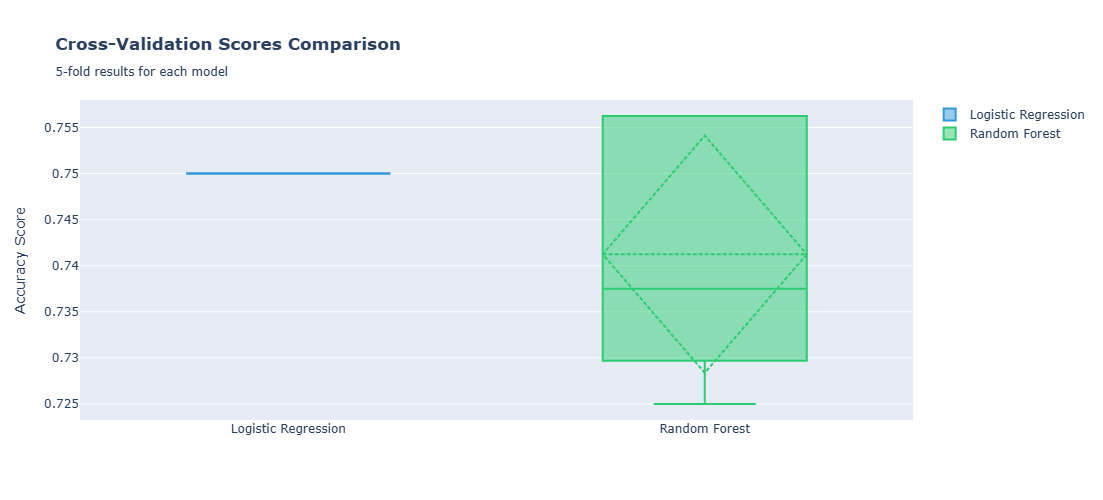

In [70]:
lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

lr_cv_scores = cross_val_score(lr_baseline, X_train_scaled, y_train, cv=5, scoring='accuracy')
rf_cv_scores = cross_val_score(rf_baseline, X_train, y_train, cv=5, scoring='accuracy')

print(f"Logistic Regression CV scores: {[f'{x:.3f}' for x in lr_cv_scores]}")
print(f"  Average: {lr_cv_scores.mean():.4f}")
print(f"\nRandom Forest CV scores: {[f'{x:.3f}' for x in rf_cv_scores]}")
print(f"  Average: {rf_cv_scores.mean():.4f}")

# Visualization 6: Cross-Validation Comparison
fig6 = go.Figure()
fig6.add_trace(go.Box(
    y=lr_cv_scores,
    name='Logistic Regression',
    marker_color='#3498db',
    boxmean='sd'
))
fig6.add_trace(go.Box(
    y=rf_cv_scores,
    name='Random Forest',
    marker_color='#2ecc71',
    boxmean='sd'
))

fig6.update_layout(
    title='<b>Cross-Validation Scores Comparison</b><br><sub>5-fold results for each model</sub>',
    yaxis_title='Accuracy Score',
    height=500,
    hovermode='closest'
)
fig6.show()

## HYPERPARAMETER TUNING
HYPERPARAMETER TUNING

In [73]:
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

lr_grid = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), 
                       lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), 
                       rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print(f"Logistic Regression best params: {lr_grid.best_params_}")
print(f"  Best score: {lr_grid.best_score_:.4f}")
print(f"\nRandom Forest best params: {rf_grid.best_params_}")
print(f"  Best score: {rf_grid.best_score_:.4f}")

# Visualization 7: Hyperparameter Tuning Results
lr_results_df = pd.DataFrame(lr_grid.cv_results_)
rf_results_df = pd.DataFrame(rf_grid.cv_results_)

fig7 = go.Figure()
fig7.add_trace(go.Scatter(
    x=list(range(len(lr_results_df))),
    y=lr_results_df['mean_test_score'].values,
    mode='markers+lines',
    name='Logistic Regression',
    marker=dict(size=8, color='#3498db'),
    line=dict(color='#3498db')
))
fig7.update_layout(
    title='<b>Hyperparameter Tuning Progress (Logistic Regression)</b><br><sub>Finding best regularization strength</sub>',
    xaxis_title='Configuration Number',
    yaxis_title='Cross-Validation Accuracy',
    height=500,
    hovermode='closest'
)
fig7.show()

Logistic Regression best params: {'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}
  Best score: 0.7500

Random Forest best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
  Best score: 0.7500


##  FINAL MODELS
TRAINING FINAL MODELS

In [75]:
lr_model = lr_grid.best_estimator_
rf_model = rf_grid.best_estimator_

y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)

y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Models trained and ready!")

Models trained and ready!


## EVALUATE MODELS
GRADING THE MODELS


LOGISTIC REGRESSION
  Accuracy:  75.0%
  Precision: 0.0%
  Recall:    0.0%
  ROC-AUC:   0.490

RANDOM FOREST
  Accuracy:  75.0%
  Precision: 0.0%
  Recall:    0.0%
  ROC-AUC:   0.495


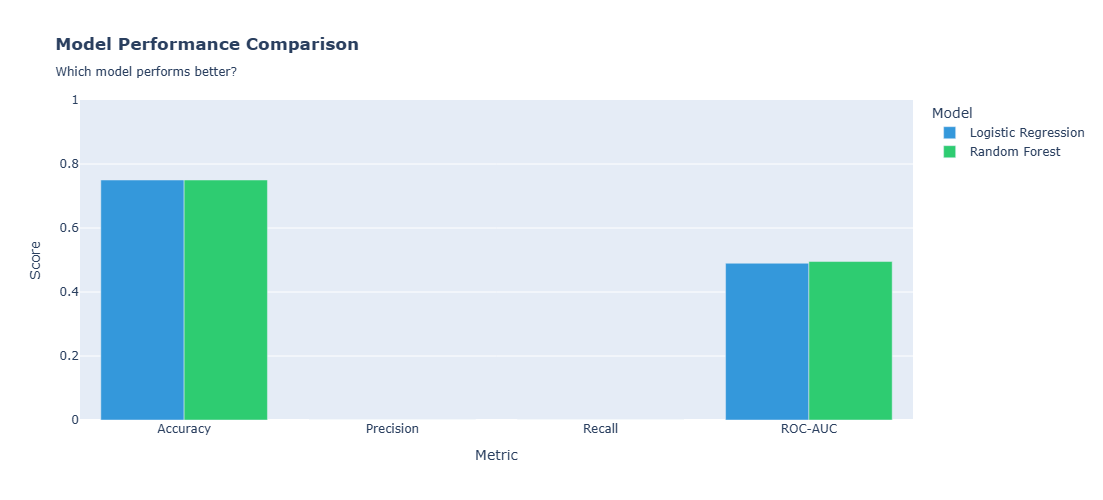

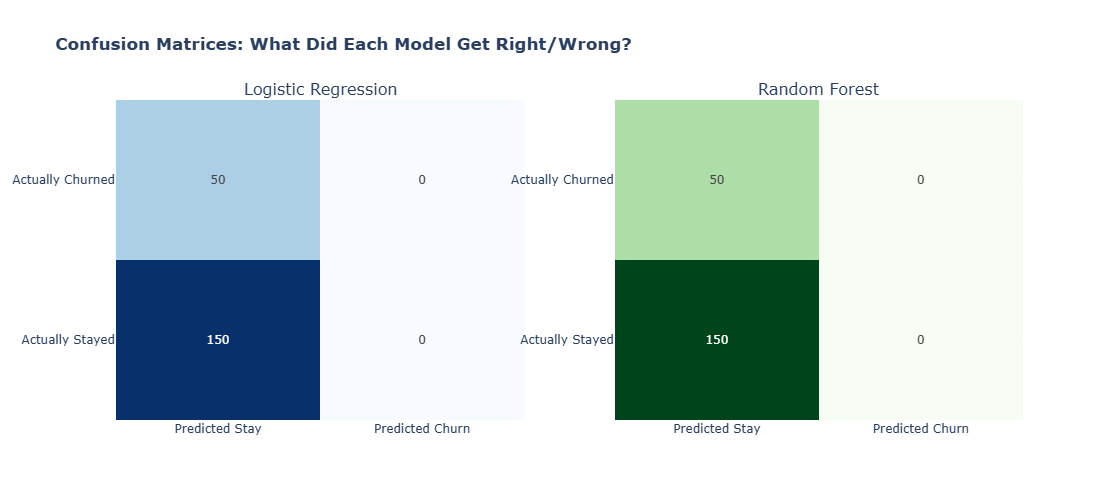

In [79]:
def evaluate_model(model_name, y_true, y_pred, y_pred_proba):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"\n{model_name.upper()}")
    print(f"  Accuracy:  {accuracy:.1%}")
    print(f"  Precision: {precision:.1%}")
    print(f"  Recall:    {recall:.1%}")
    print(f"  ROC-AUC:   {roc_auc:.3f}")
    
    return accuracy, precision, recall, roc_auc

acc_lr, prec_lr, rec_lr, auc_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_pred_proba_lr)
acc_rf, prec_rf, rec_rf, auc_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_pred_proba_rf)

# Visualization 8: Model Performance Metrics
metrics_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Logistic Regression', 'Logistic Regression', 'Logistic Regression',
              'Random Forest', 'Random Forest', 'Random Forest', 'Random Forest'],
    'Metric': ['Accuracy', 'Precision', 'Recall', 'ROC-AUC'] * 2,
    'Score': [acc_lr, prec_lr, rec_lr, auc_lr, acc_rf, prec_rf, rec_rf, auc_rf]
})

fig8 = px.bar(metrics_df, x='Metric', y='Score', color='Model',
              barmode='group',
              color_discrete_map={'Logistic Regression': '#3498db', 'Random Forest': '#2ecc71'},
              title='<b>Model Performance Comparison</b><br><sub>Which model performs better?</sub>')
fig8.update_yaxes(range=[0, 1])
fig8.update_layout(height=500)
fig8.show()

# Visualization 9: Confusion Matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig9 = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Logistic Regression', 'Random Forest'),
    specs=[[{'type': 'heatmap'}, {'type': 'heatmap'}]]
)
fig9.add_trace(
    go.Heatmap(z=cm_lr, x=['Predicted Stay', 'Predicted Churn'], 
               y=['Actually Stayed', 'Actually Churned'],
               text=cm_lr, texttemplate='%{text}', colorscale='Blues',
               showscale=False, hovertemplate='%{y}<br>%{x}<br>Count: %{z}<extra></extra>'),
    row=1, col=1
)

fig9.add_trace(
    go.Heatmap(z=cm_rf, x=['Predicted Stay', 'Predicted Churn'],
               y=['Actually Stayed', 'Actually Churned'],
               text=cm_rf, texttemplate='%{text}', colorscale='Greens',
               showscale=False, hovertemplate='%{y}<br>%{x}<br>Count: %{z}<extra></extra>'),
    row=1, col=2
)

fig9.update_layout(
    title='<b>Confusion Matrices: What Did Each Model Get Right/Wrong?</b>',
    height=500,
    showlegend=False
)
fig9.show()

## ROC CURVES

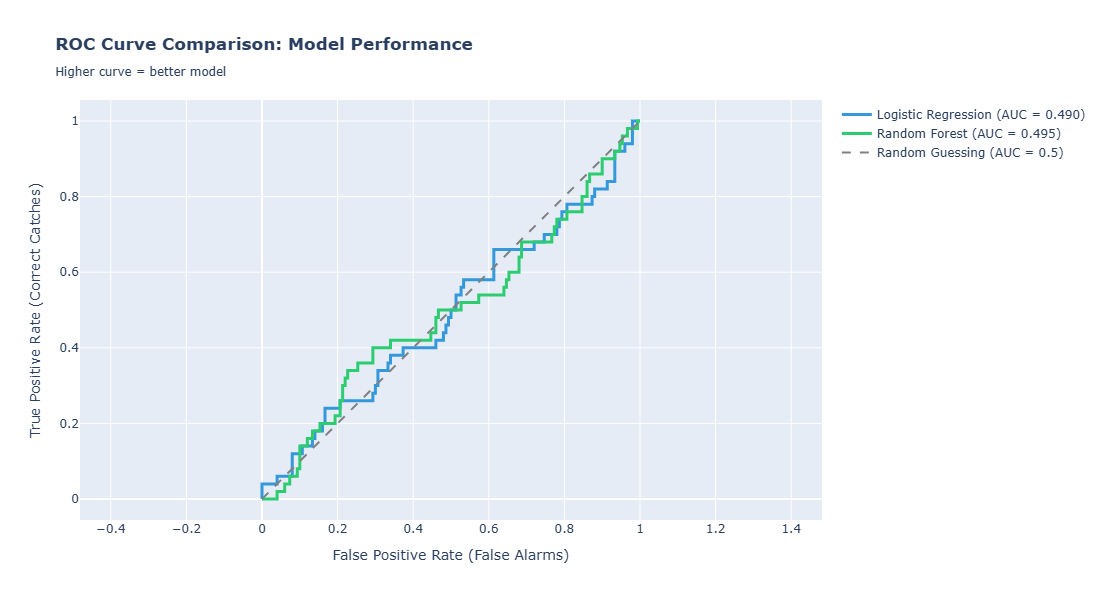

In [81]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

fig10 = go.Figure()

fig10.add_trace(go.Scatter(
    x=fpr_lr, y=tpr_lr,
    mode='lines',
    name=f'Logistic Regression (AUC = {auc_lr:.3f})',
    line=dict(color='#3498db', width=3)
))

fig10.add_trace(go.Scatter(
    x=fpr_rf, y=tpr_rf,
    mode='lines',
    name=f'Random Forest (AUC = {auc_rf:.3f})',
    line=dict(color='#2ecc71', width=3)
))
fig10.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Random Guessing (AUC = 0.5)',
    line=dict(color='gray', width=2, dash='dash')
))

fig10.update_layout(
    title='<b>ROC Curve Comparison: Model Performance</b><br><sub>Higher curve = better model</sub>',
    xaxis_title='False Positive Rate (False Alarms)',
    yaxis_title='True Positive Rate (Correct Catches)',
    height=600,
    hovermode='closest',
    xaxis=dict(scaleanchor="y", scaleratio=1),
    yaxis=dict(scaleanchor="x", scaleratio=1)
)
fig10.show()

## FEATURE IMPORTANCE


Top 10 Most Important Factors:
                       feature  importance
                 total_charges    0.246043
               monthly_charges    0.238141
                 tenure_months    0.194545
                           age    0.188705
        contract_length_2 year    0.043384
  internet_service_Fiber optic    0.033930
           internet_service_No    0.029946
contract_length_Month-to-month    0.025306


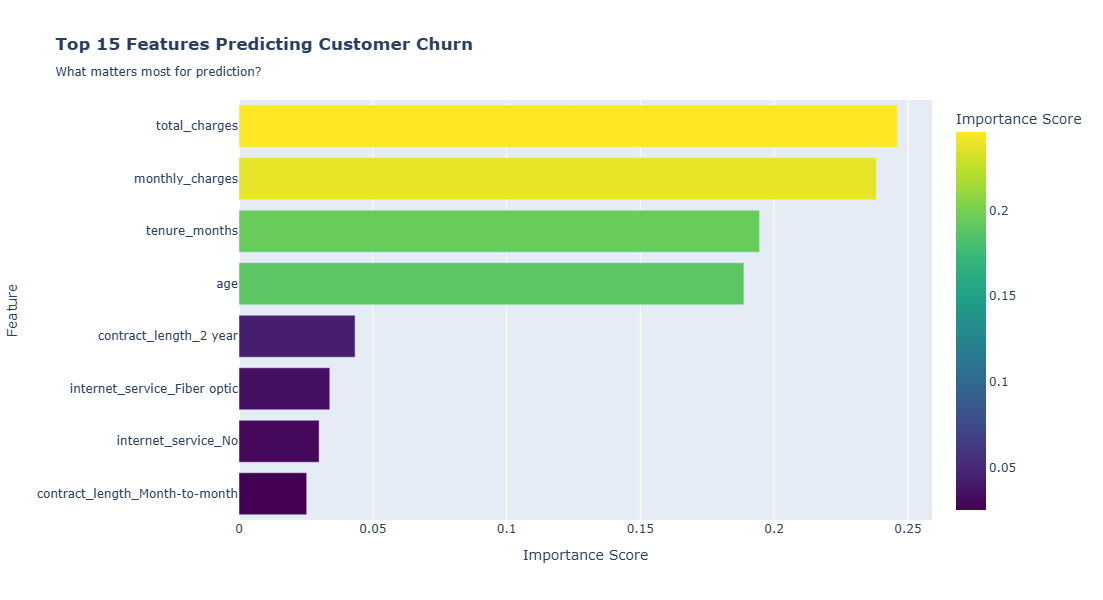

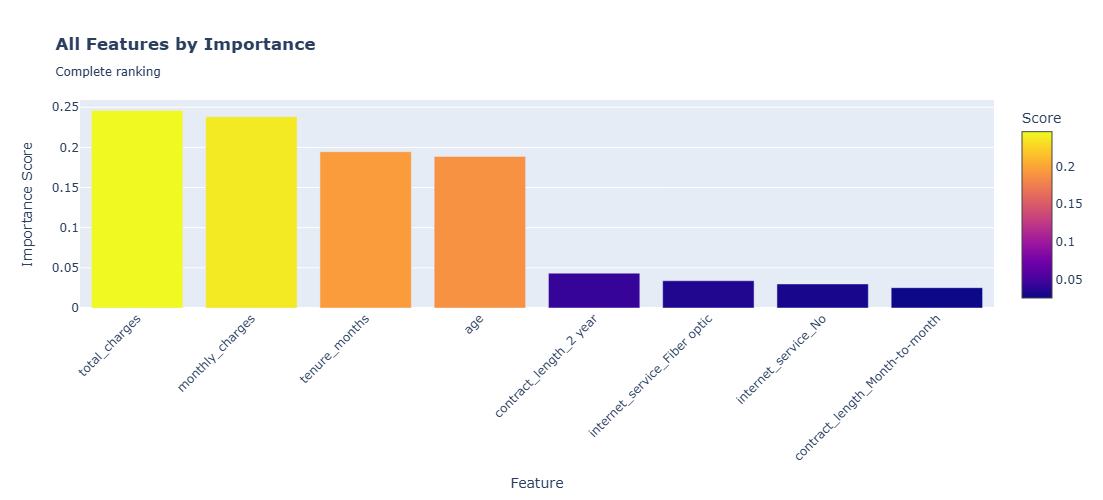

In [83]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Factors:")
print(feature_importance.head(10).to_string(index=False))

# Visualization 11: Feature Importance Bar Chart
fig11 = px.bar(feature_importance.head(15),
               x='importance', y='feature',
               orientation='h',
               title='<b>Top 15 Features Predicting Customer Churn</b><br><sub>What matters most for prediction?</sub>',
               labels={'importance': 'Importance Score', 'feature': 'Feature'},
               color='importance',
               color_continuous_scale='Viridis')

fig11.update_yaxes(categoryorder='total ascending')
fig11.update_layout(height=600, showlegend=False)
fig11.show()

# Visualization 12: Feature Importance Distribution
fig12 = go.Figure()
fig12.add_trace(go.Bar(
    x=feature_importance['feature'],
    y=feature_importance['importance'],
    marker=dict(
        color=feature_importance['importance'],
        colorscale='Plasma',
        showscale=True,
        colorbar=dict(title="Score")
    ),
    hovertemplate='<b>%{x}</b><br>Importance: %{y:.4f}<extra></extra>'
))

fig12.update_layout(
    title='<b>All Features by Importance</b><br><sub>Complete ranking</sub>',
    xaxis_title='Feature',
    yaxis_title='Importance Score',
    height=500,
    xaxis_tickangle=-45
)
fig12.show()

## PREDICTIONS ON NEW DATA
MAKING PREDICTIONS ON NEW CUSTOMERS


Sample Customer Prediction:
  Age: 35, Tenure: 6 months, Monthly: $89.50, Contract: Month-to-month, Internet: Fiber optic
  Logistic Regression: 25.3%
  Random Forest: 24.7%
  Average Risk: 25.0%


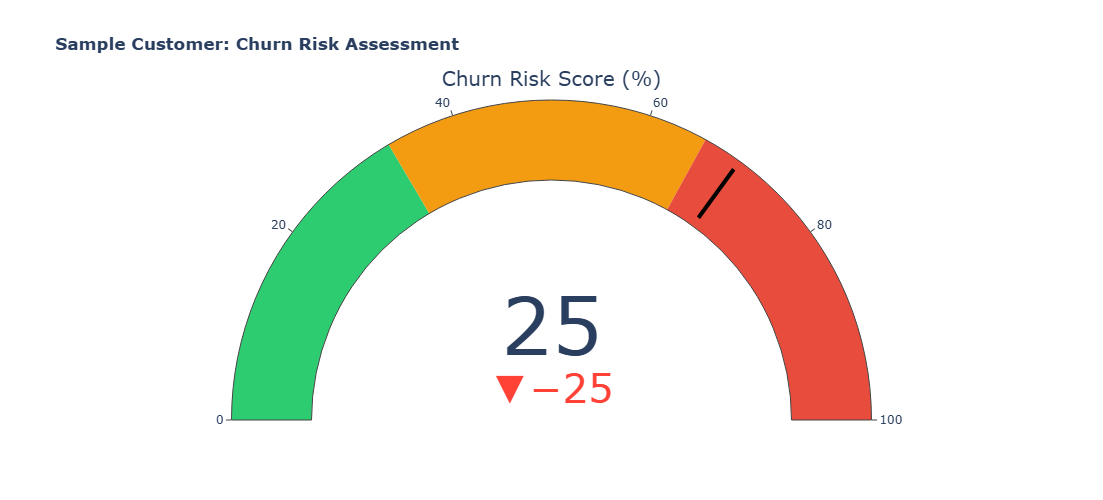

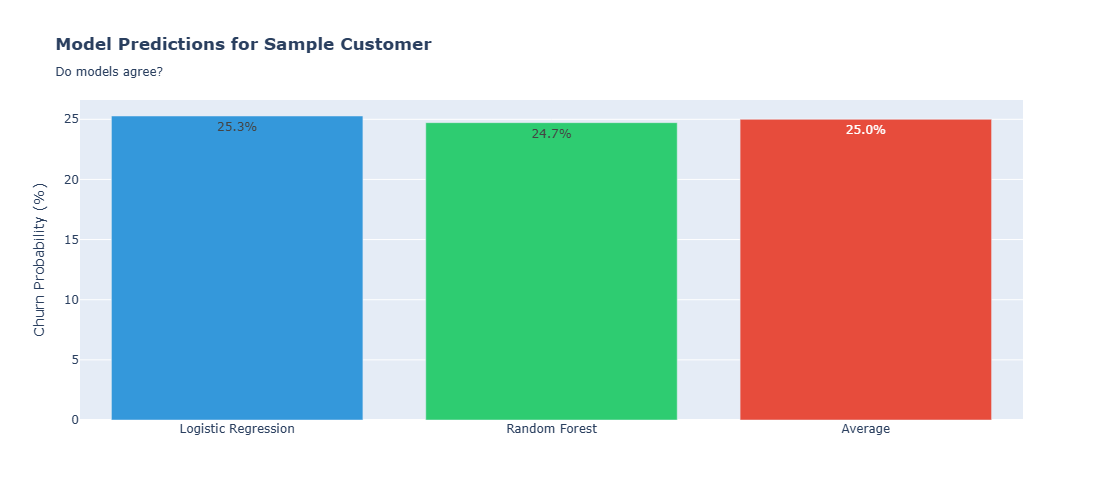


Generating risk classification for all test customers...


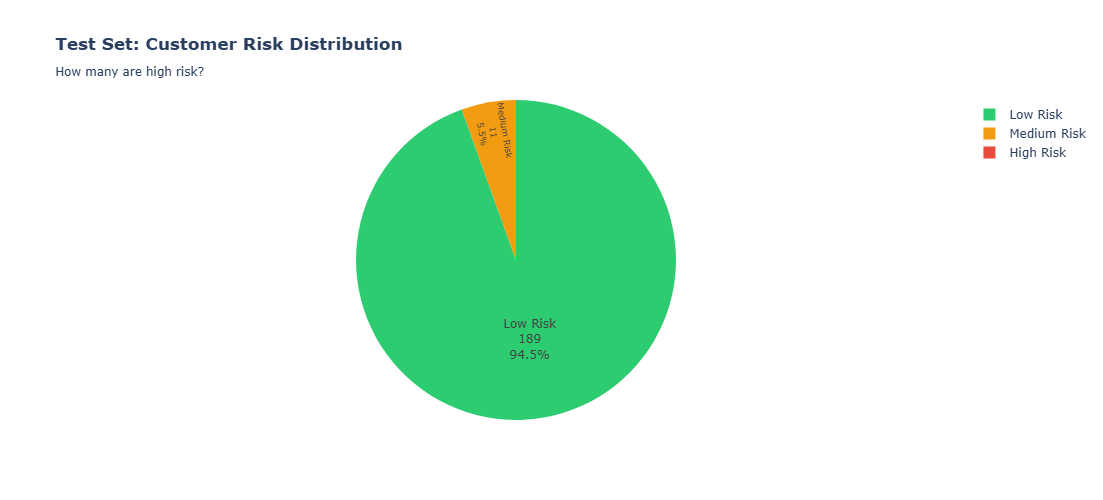

In [86]:
new_customer = pd.DataFrame({
    'age': [35],
    'tenure_months': [6],
    'monthly_charges': [89.5],
    'total_charges': [537],
    'contract_length_1 year': [0],
    'contract_length_2 year': [0],
    'internet_service_Fiber optic': [1],
    'internet_service_No': [0]
})

for col in X.columns:
    if col not in new_customer.columns:
        new_customer[col] = 0

new_customer = new_customer[X.columns]

churn_prob_lr = lr_model.predict_proba(scaler.transform(new_customer))[0][1]
churn_prob_rf = rf_model.predict_proba(new_customer)[0][1]
avg_prob = (churn_prob_lr + churn_prob_rf) / 2

print(f"\nSample Customer Prediction:")
print(f"  Age: 35, Tenure: 6 months, Monthly: $89.50, Contract: Month-to-month, Internet: Fiber optic")
print(f"  Logistic Regression: {churn_prob_lr:.1%}")
print(f"  Random Forest: {churn_prob_rf:.1%}")
print(f"  Average Risk: {avg_prob:.1%}")

# Visualization 13: Prediction Gauge
fig13 = go.Figure(go.Indicator(
    mode="gauge+number+delta",
    value=avg_prob * 100,
    domain={'x': [0, 1], 'y': [0, 1]},
    title={'text': "Churn Risk Score (%)"},
    delta={'reference': 50},
    gauge={
        'axis': {'range': [0, 100]},
        'bar': {'color': "#2ecc71"},
        'steps': [
            {'range': [0, 33], 'color': "#2ecc71"},
            {'range': [33, 66], 'color': "#f39c12"},
            {'range': [66, 100], 'color': "#e74c3c"}
        ],
        'threshold': {
            'line': {'color': "black", 'width': 4},
            'thickness': 0.75,
            'value': 70
        }
    }
))

fig13.update_layout(height=500, title_text="<b>Sample Customer: Churn Risk Assessment</b>")
fig13.show()

# Visualization 14: Model Prediction Comparison
models = ['Logistic Regression', 'Random Forest', 'Average']
probs = [churn_prob_lr * 100, churn_prob_rf * 100, avg_prob * 100]
colors = ['#3498db', '#2ecc71', '#e74c3c']

fig14 = go.Figure(data=[
    go.Bar(x=models, y=probs, marker_color=colors,
           text=[f'{p:.1f}%' for p in probs],
           textposition='auto',
           hovertemplate='<b>%{x}</b><br>Churn Risk: %{y:.1f}%<extra></extra>')
])
fig14.update_layout(
    title='<b>Model Predictions for Sample Customer</b><br><sub>Do models agree?</sub>',
    yaxis_title='Churn Probability (%)',
    height=500,
    showlegend=False
)
fig14.show()

# Visualization 15: Risk Classification Distribution
print("\nGenerating risk classification for all test customers...")
all_probs_rf = rf_model.predict_proba(X_test)[:, 1]
risk_categories = pd.cut(all_probs_rf, bins=[0, 0.33, 0.66, 1.0],
                         labels=['Low Risk', 'Medium Risk', 'High Risk'])
risk_counts = risk_categories.value_counts()

fig15 = go.Figure(data=[
    go.Pie(
        labels=risk_counts.index,
        values=risk_counts.values,
        marker=dict(colors=['#2ecc71', '#f39c12', '#e74c3c']),
        textposition='inside',
        textinfo='label+percent+value',
        hovertemplate='<b>%{label}</b><br>Customers: %{value}<br>Percentage: %{percent}<extra></extra>'
    )
])
fig15.update_layout(
    title='<b>Test Set: Customer Risk Distribution</b><br><sub>How many are high risk?</sub>',
    height=500
)
fig15.show()

